In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
network = pypsa.Network(
    "../../resources/network/Historical_2015_reduced_solved.nc"
)

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Historical_2015_reduced (Full)' has buses, carriers, generators, lines, links, loads, storage_units, sub_networks


In [4]:
network 

PyPSA Network 'Historical_2015_reduced (Full)'
----------------------------------------------
Components:
 - Bus: 34
 - Carrier: 88
 - Generator: 1721
 - Line: 99
 - Link: 6
 - Load: 35
 - StorageUnit: 7
 - SubNetwork: 1
Snapshots: 168

## 1. Baseline Network Analysis

This notebook analyses the Historical_2015_reduced PyPSA-GB baseline scenario.

The initial objectives are to:

- inspect network topology and generation composition;
- identify binding transmission constraints;
- quantify renewable curtailment;
- examine the relationship between congestion and wind curtailment;
- establish a baseline for later BESS and market-design experiments.

In [5]:
# Basic model information

print("Scenario:", network.name)
print("Snapshots:", len(network.snapshots))
print("Start:", network.snapshots[0])
print("End:", network.snapshots[-1])

print("\nNetwork components")
print("------------------")
print("Buses:", len(network.buses))
print("Lines:", len(network.lines))
print("Generators:", len(network.generators))
print("Loads:", len(network.loads))
print("Storage units:", len(network.storage_units))
print("Links:", len(network.links))

Scenario: Historical_2015_reduced (Full)
Snapshots: 168
Start: 2015-01-01 00:00:00
End: 2015-01-07 23:00:00

Network components
------------------
Buses: 34
Lines: 99
Generators: 1721
Loads: 35
Storage units: 7
Links: 6


## 2. Transmission Congestion Analysis

For each transmission line, calculate the maximum observed active power flow and compare it with the modelled line limit.

The purpose is to identify lines that become binding during the optimisation window.

In [ ]:
line_analysis = network.lines[
    ["bus0", "bus1", "s_nom", "s_max_pu"]
].copy()

# Maximum absolute active power flow on each line
line_analysis["max_flow_MW"] = network.lines_t.p0.abs().max()

# Effective modelled line limit
line_analysis["effective_limit_MW"] = (
    line_analysis["s_nom"] * line_analysis["s_max_pu"]
)

# Maximum loading percentage
line_analysis["max_loading_pct"] = (
    100
    * line_analysis["max_flow_MW"]
    / line_analysis["effective_limit_MW"]
)

# Sort from most heavily loaded to least loaded
line_analysis = line_analysis.sort_values(
    "max_loading_pct",
    ascending=False
)

line_analysis.head(15)

,bus0,bus1,s_nom,s_max_pu,max_flow_MW,effective_limit_MW,max_loading_pct
name,,,,,,,
16,Neilston,Deeside,2200.0,1.0,2200.000000,2200.0,100.000000
3,Beauly,Errochty,132.0,1.0,132.000000,132.0,100.000000
1,Beauly,Errochty,132.0,1.0,132.000000,132.0,100.000000
61,Feckenham,Melksham,1970.0,1.0,1668.033819,1970.0,84.671767
62,Feckenham,Melksham,1970.0,1.0,1668.033819,1970.0,84.671767
58,Ratcliffe,Sundon/East Claydon,2100.0,1.0,1490.563396,2100.0,70.979209
57,Ratcliffe,Sundon/East Claydon,2100.0,1.0,1490.563396,2100.0,70.979209
0,Beauly,Peterhead,525.0,1.0,352.354443,525.0,67.115132
2,Beauly,Peterhead,525.0,1.0,352.354443,525.0,67.115132


In [7]:
# Calculate hourly loading as a fraction of each line's effective limit
line_loading = network.lines_t.p0.abs().div(
    line_analysis["effective_limit_MW"],
    axis=1
)

# Count how many hours each line is at or above 99% loading
line_analysis["hours_ge_99pct"] = (
    line_loading >= 0.99
).sum()

# Show the most constrained lines
line_analysis[
    [
        "bus0",
        "bus1",
        "effective_limit_MW",
        "max_loading_pct",
        "hours_ge_99pct"
    ]
].head(15)

,bus0,bus1,effective_limit_MW,max_loading_pct,hours_ge_99pct
name,,,,,
16,Neilston,Deeside,2200.0,100.000000,168
3,Beauly,Errochty,132.0,100.000000,76
1,Beauly,Errochty,132.0,100.000000,76
61,Feckenham,Melksham,1970.0,84.671767,0
62,Feckenham,Melksham,1970.0,84.671767,0
58,Ratcliffe,Sundon/East Claydon,2100.0,70.979209,0
57,Ratcliffe,Sundon/East Claydon,2100.0,70.979209,0
0,Beauly,Peterhead,525.0,67.115132,0
2,Beauly,Peterhead,525.0,67.115132,0


## 3. Beauly Wind Curtailment Analysis

Beauly contains a large concentration of onshore wind capacity.

This section compares:

- available wind generation;
- actual dispatched wind generation;
- implied wind curtailment;
- transmission congestion on the Beauly–Errochty corridor.

Curtailment is calculated as available renewable generation minus actual dispatched generation.

In [9]:
beauly_wind = network.generators[
    (network.generators["bus"] == "Beauly")
    & (network.generators["carrier"] == "wind_onshore")
]

beauly_wind.head()

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,lon,lat,ro_banding,cfd_round,data_source,region
name,,,,,,,,,,,,,,,,,,,,,
Kilbraur_Windfarm_Farlary___Extension,Beauly,PQ,,20.0,0.0,False,0.0,inf,NaN,0.0,...,1.0,1.0,1.0,20.0,-3.978666,57.992370,NaN,,,
Millennium_Extension_II,Beauly,PQ,,15.0,0.0,False,0.0,inf,NaN,0.0,...,1.0,1.0,1.0,15.0,-4.883634,57.155209,NaN,,,
Lairg_Wind_Farm,Beauly,PQ,,7.5,0.0,False,0.0,inf,NaN,0.0,...,1.0,1.0,1.0,7.5,-4.348703,58.002713,NaN,,,
Beinn_Tharsuinn_Extension_Beinn_nan_Oighrean,Beauly,PQ,,4.6,0.0,False,0.0,inf,NaN,0.0,...,1.0,1.0,1.0,4.6,-4.248151,57.788210,NaN,,,
Boulfruich,Beauly,PQ,,13.0,0.0,False,0.0,inf,NaN,0.0,...,1.0,1.0,1.0,13.0,-3.443361,58.299924,NaN,,,


In [10]:
beauly_wind_capacity = beauly_wind["p_nom"].sum()

print(
    "Beauly onshore wind capacity:",
    round(beauly_wind_capacity, 1),
    "MW"
)

Beauly onshore wind capacity: 1102.5 MW


In [11]:
# Generator names
beauly_wind_names = beauly_wind.index

# Maximum wind generation possible in each hour
wind_available = (
    network.generators_t.p_max_pu[beauly_wind_names]
    .mul(beauly_wind["p_nom"], axis=1)
    .sum(axis=1)
)

# Actual optimised wind dispatch
wind_dispatch = (
    network.generators_t.p[beauly_wind_names]
    .sum(axis=1)
)

# Implied curtailment
wind_curtailment = (
    wind_available - wind_dispatch
).clip(lower=0)

print("Available:", round(wind_available.sum(), 1), "MWh")
print("Dispatched:", round(wind_dispatch.sum(), 1), "MWh")
print("Curtailed:", round(wind_curtailment.sum(), 1), "MWh")

print(
    "Curtailment rate:",
    round(
        100 * wind_curtailment.sum() / wind_available.sum(),
        2
    ),
    "%"
)

Available: 97748.7 MWh
Dispatched: 95758.1 MWh
Curtailed: 1990.6 MWh
Curtailment rate: 2.04 %


### 3.1 Wind Curtailment and Network Congestion

The hourly wind availability and dispatch results are combined with loading on the
Beauly–Errochty transmission corridor.

A line is classified as constrained when its loading is at or above 99% of its
modelled limit.

In [12]:
# Beauly–Errochty transmission line used for this initial analysis
beauly_line = "1"

# Hourly loading of the line
beauly_line_loading = line_loading[beauly_line] * 100

# Build one analysis dataframe
beauly_analysis = pd.DataFrame({
    "wind_available_MW": wind_available,
    "wind_dispatch_MW": wind_dispatch,
    "wind_curtailment_MW": wind_curtailment,
    "line_loading_pct": beauly_line_loading
})

# Identify constrained hours
beauly_analysis["constrained"] = (
    beauly_analysis["line_loading_pct"] >= 99
)

beauly_analysis.head(10)

,wind_available_MW,wind_dispatch_MW,wind_curtailment_MW,line_loading_pct,constrained
snapshot,,,,,
2015-01-01 00:00:00,808.410707,808.410707,0.000000e+00,100.0,True
2015-01-01 01:00:00,834.625373,834.625373,0.000000e+00,100.0,True
2015-01-01 02:00:00,877.411504,870.652767,6.758737e+00,100.0,True
2015-01-01 03:00:00,860.615057,739.823744,1.207913e+02,100.0,True
2015-01-01 04:00:00,775.694167,745.248118,3.044605e+01,100.0,True
2015-01-01 05:00:00,671.401556,671.401556,0.000000e+00,100.0,True
2015-01-01 06:00:00,640.697911,640.697911,1.110720e-10,100.0,True
2015-01-01 07:00:00,613.573822,613.573822,0.000000e+00,100.0,True
2015-01-01 08:00:00,561.719589,561.719589,8.913048e-11,100.0,True


In [13]:
# Compare constrained and unconstrained hours
congestion_comparison = (
    beauly_analysis
    .groupby("constrained")
    .agg(
        hours=("wind_curtailment_MW", "count"),
        avg_available_wind_MW=("wind_available_MW", "mean"),
        avg_dispatch_MW=("wind_dispatch_MW", "mean"),
        avg_curtailment_MW=("wind_curtailment_MW", "mean"),
        total_curtailment_MWh=("wind_curtailment_MW", "sum")
    )
)

congestion_comparison

,hours,avg_available_wind_MW,avg_dispatch_MW,avg_curtailment_MW,total_curtailment_MWh
constrained,,,,,
False,92,437.511437,437.511437,4.692455e-11,4.317059e-09
True,76,756.547670,730.356220,2.619145e+01,1.990550e+03


In [ ]:
## 4. Baseline Wind Curtailment Visualisation

The following figure compares hourly available wind generation with actual dispatched
wind generation at Beauly. The gap between the two represents implied wind curtailment.

In [4]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load solved network
network = pypsa.Network(
    "../../resources/network/Historical_2015_reduced_solved.nc"
)

# Select Beauly onshore wind generators
beauly_wind = network.generators[
    (network.generators["bus"] == "Beauly")
    & (network.generators["carrier"] == "wind_onshore")
]

beauly_wind_names = beauly_wind.index

# Available wind
wind_available = (
    network.generators_t.p_max_pu[beauly_wind_names]
    .mul(beauly_wind["p_nom"], axis=1)
    .sum(axis=1)
)

# Actual wind dispatch
wind_dispatch = (
    network.generators_t.p[beauly_wind_names]
    .sum(axis=1)
)

# Wind curtailment
wind_curtailment = (
    wind_available - wind_dispatch
).clip(lower=0)

# Remove tiny numerical noise
wind_curtailment[wind_curtailment < 1e-6] = 0

# Beauly -> Errochty line
beauly_line = "1"

line_limit = (
    network.lines.at[beauly_line, "s_nom"]
    * network.lines.at[beauly_line, "s_max_pu"]
)

beauly_line_loading = (
    network.lines_t.p0[beauly_line].abs()
    / line_limit
    * 100
)

# Build combined dataframe
beauly_analysis = pd.DataFrame({
    "wind_available_MW": wind_available,
    "wind_dispatch_MW": wind_dispatch,
    "wind_curtailment_MW": wind_curtailment,
    "line_loading_pct": beauly_line_loading
})

beauly_analysis["constrained"] = (
    beauly_analysis["line_loading_pct"] >= 99
)

beauly_analysis.head()

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Historical_2015_reduced (Full)' has buses, carriers, generators, lines, links, loads, storage_units, sub_networks


,wind_available_MW,wind_dispatch_MW,wind_curtailment_MW,line_loading_pct,constrained
snapshot,,,,,
2015-01-01 00:00:00,808.410707,808.410707,0.000000,100.0,True
2015-01-01 01:00:00,834.625373,834.625373,0.000000,100.0,True
2015-01-01 02:00:00,877.411504,870.652767,6.758737,100.0,True
2015-01-01 03:00:00,860.615057,739.823744,120.791313,100.0,True
2015-01-01 04:00:00,775.694167,745.248118,30.446049,100.0,True


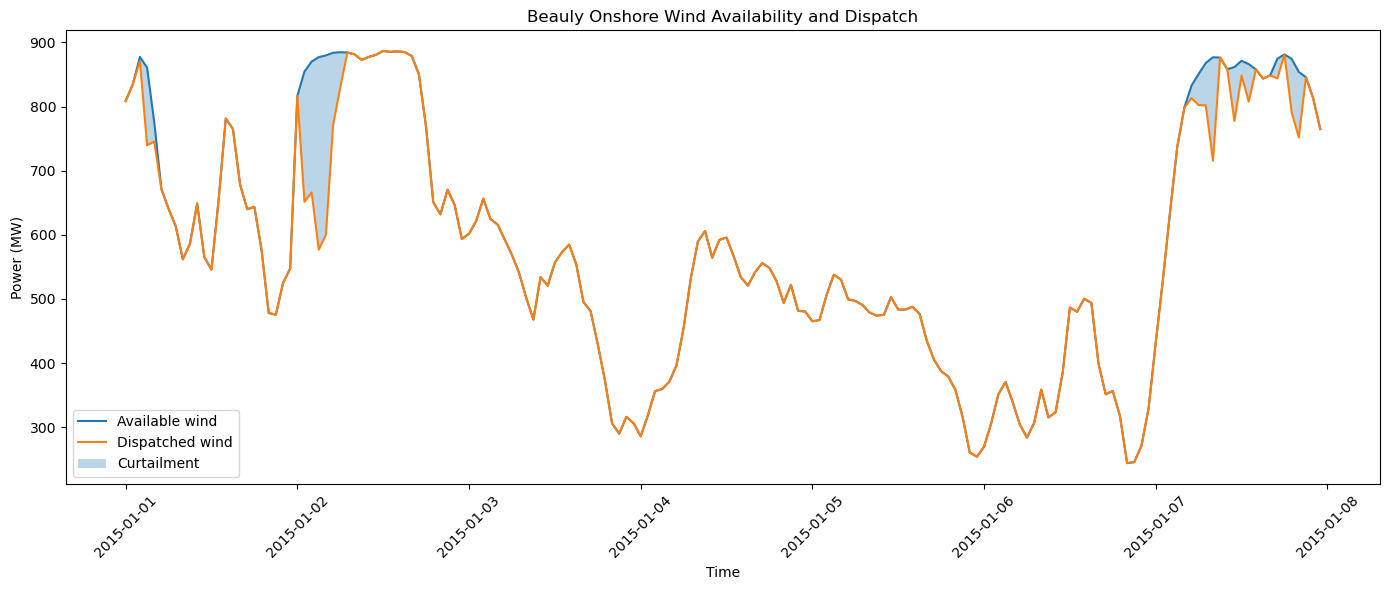

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    beauly_analysis.index,
    beauly_analysis["wind_available_MW"],
    label="Available wind"
)

ax.plot(
    beauly_analysis.index,
    beauly_analysis["wind_dispatch_MW"],
    label="Dispatched wind"
)

ax.fill_between(
    beauly_analysis.index,
    beauly_analysis["wind_dispatch_MW"],
    beauly_analysis["wind_available_MW"],
    alpha=0.3,
    label="Curtailment"
)

ax.set_title("Beauly Onshore Wind Availability and Dispatch")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Time")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# List active scenarios
python -c "
import yaml
with open('config/config.yaml') as f:
    config = yaml.safe_load(f)
print('Active scenarios:', config.get('run_scenarios', []))
"

SyntaxError: unterminated string literal (detected at line 2) (1372419365.py, line 2)